In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("spam_ham_dataset.csv")

df = df.drop(columns=['Unnamed: 0'])
df = df.dropna()

X = df['text']
y = df['label_num']

print(df['label'].value_counts())

label
ham     3672
spam    1499
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9893719806763285
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       742
           1       0.98      0.99      0.98       293

    accuracy                           0.99      1035
   macro avg       0.99      0.99      0.99      1035
weighted avg       0.99      0.99      0.99      1035



In [20]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[735   7]
 [  4 289]]


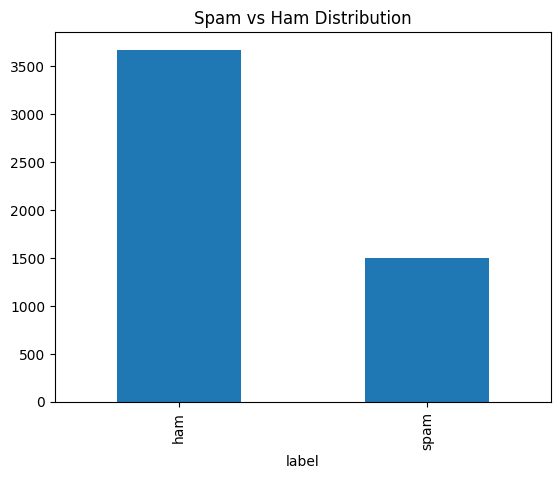

In [21]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.show()

In [22]:
#Test Inputs
test_emails = [
    "Congratulations! You have won a free laptop.",
    "Let's meet at 5pm today.",
    "Earn money fast with this simple trick!",
    "Please review the attached file.",
]

test_vec = vectorizer.transform(test_emails)
predictions = model.predict(test_vec)

for email, pred in zip(test_emails, predictions):
    print(f"\nEmail: {email}")
    print("Prediction:", "Spam ❌" if pred == 1 else "Not Spam ✅")


Email: Congratulations! You have won a free laptop.
Prediction: Spam ❌

Email: Let's meet at 5pm today.
Prediction: Not Spam ✅

Email: Earn money fast with this simple trick!
Prediction: Spam ❌

Email: Please review the attached file.
Prediction: Not Spam ✅
